# SALES PREDICTION PROJECT - CODE ALPHA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# DATASET IMPORT 
df = pd.read_csv('advertising.csv')
print("-- Dataset Preview --")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

-- Dataset Preview --
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
5           6    8.7   48.9       75.0    7.2
6           7   57.5   32.8       23.5   11.8
7           8  120.2   19.6       11.6   13.2
8           9    8.6    2.1        1.0    4.8
9          10  199.8    2.6       21.2   10.6

Shape: (200, 5)

Columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Data types:
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


# Data Cleaning & Exploration

In [4]:
# Basic statistics
print("=== Summary Stats ===")
print(df.describe())

# Clean column names
df.columns = df.columns.str.strip().str.lower()
print(f"\nCleaned columns: {df.columns.tolist()}")

# Drop missing values if any
df.dropna(inplace=True)
print(f"\nFinal dataset shape: {df.shape}")

# Correlation with Sales
print("\n=== Correlation with Sales ===")
print(df.corr()['sales'].sort_values(ascending=False))

=== Summary Stats ===
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000

Cleaned columns: ['unnamed: 0', 'tv', 'radio', 'newspaper', 'sales']

Final dataset shape: (200, 5)

=== Correlation with Sales ===
sales         1.000000
tv            0.782224
radio         0.576223
newspaper     0.228299
unnamed: 0   -0.051616
Name: sales, dtype: float64


# Visualisation v1: Distribution & Correlation

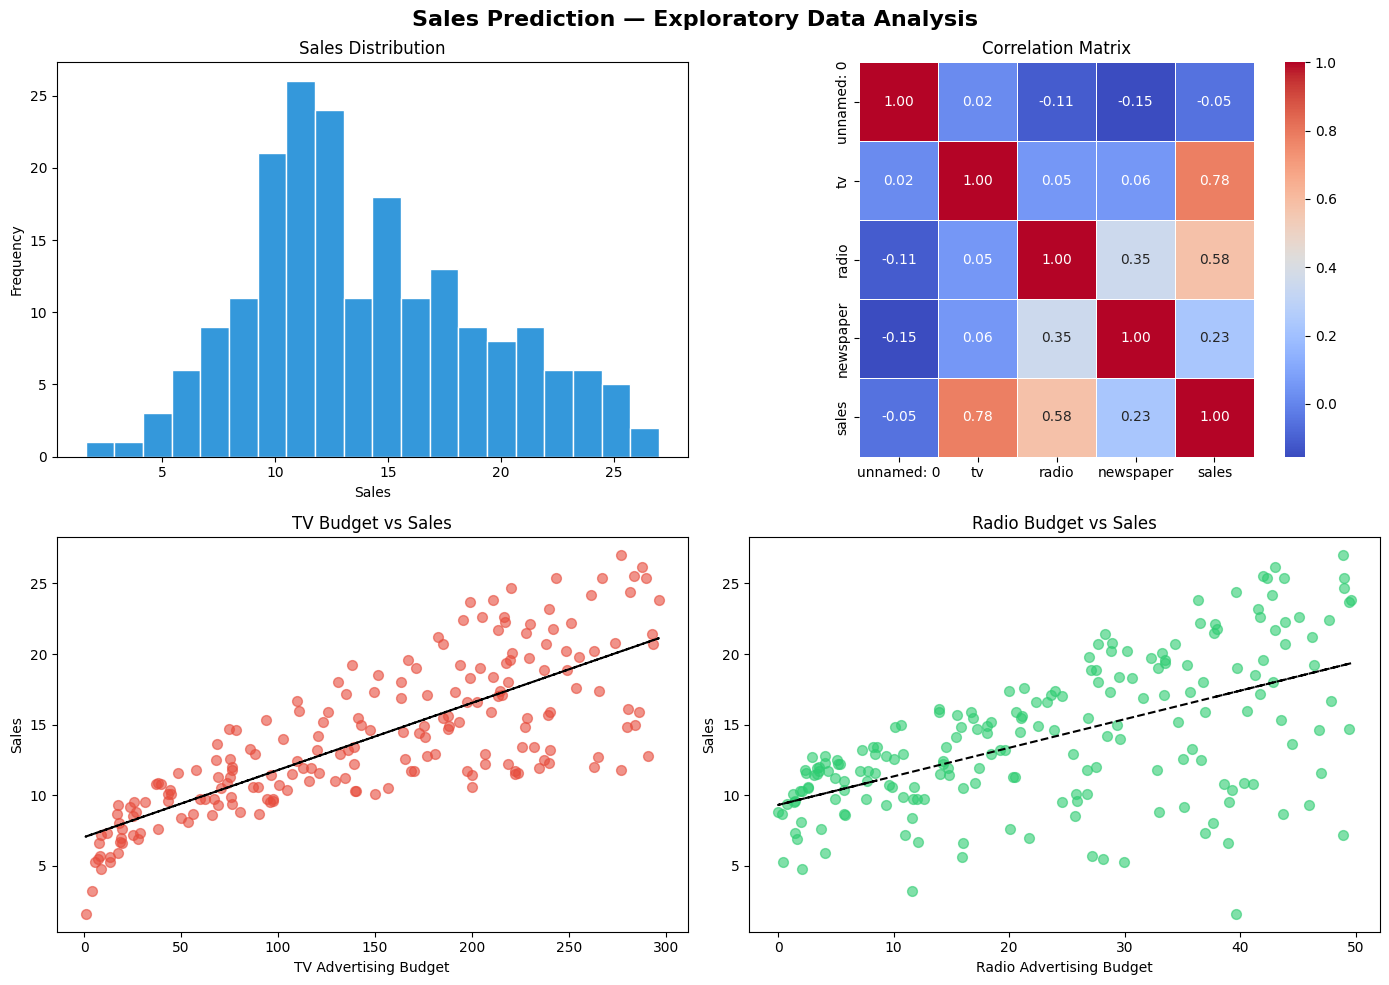

Chart saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Prediction — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Sales distribution
axes[0, 0].hist(df['sales'], bins=20, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Sales Distribution')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# 2. Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0, 1], square=True, linewidths=0.5)
axes[0, 1].set_title('Correlation Matrix')

# 3. TV spend vs Sales
axes[1, 0].scatter(df['tv'], df['sales'], color='#e74c3c', alpha=0.6, s=50)
axes[1, 0].set_xlabel('TV Advertising Budget')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].set_title('TV Budget vs Sales')

# Add regression line
m, b = np.polyfit(df['tv'], df['sales'], 1)
axes[1, 0].plot(df['tv'], m * df['tv'] + b, color='black', linewidth=1.5, linestyle='--')

# 4. Radio spend vs Sales
axes[1, 1].scatter(df['radio'], df['sales'], color='#2ecc71', alpha=0.6, s=50)
axes[1, 1].set_xlabel('Radio Advertising Budget')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].set_title('Radio Budget vs Sales')

m2, b2 = np.polyfit(df['radio'], df['sales'], 1)
axes[1, 1].plot(df['radio'], m2 * df['radio'] + b2, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('eda_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

# Visualisation v2: Advertising Budget Breakdown

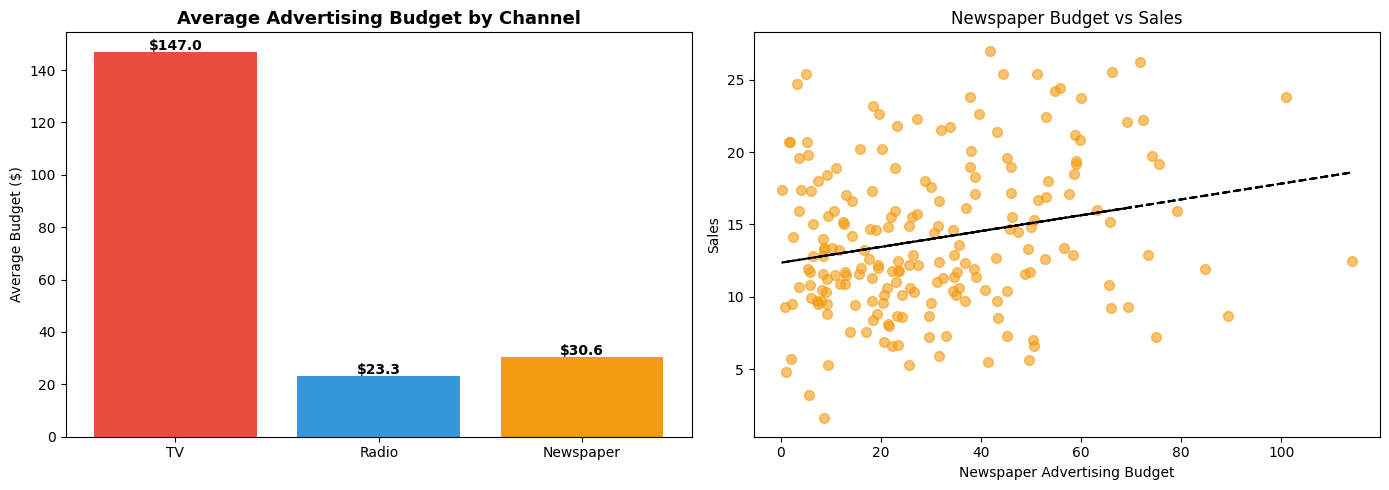

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average budget per channel
channels = ['tv', 'radio', 'newspaper']
averages = [df[c].mean() for c in channels]
colors   = ['#e74c3c', '#3498db', '#f39c12']

bars = axes[0].bar(['TV', 'Radio', 'Newspaper'], averages, color=colors)
axes[0].set_title('Average Advertising Budget by Channel', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Budget ($)')
for bar, val in zip(bars, averages):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', fontweight='bold')

# Right: Newspaper spend vs Sales
axes[1].scatter(df['newspaper'], df['sales'], color='#f39c12', alpha=0.6, s=50)
axes[1].set_xlabel('Newspaper Advertising Budget')
axes[1].set_ylabel('Sales')
axes[1].set_title('Newspaper Budget vs Sales')

m3, b3 = np.polyfit(df['newspaper'], df['sales'], 1)
axes[1].plot(df['newspaper'], m3 * df['newspaper'] + b3,
             color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('budget_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Data Preparation

In [7]:
# Features and target
X = df[['tv', 'radio', 'newspaper']]
y = df['sales']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nFeatures used: {X.columns.tolist()}")

Training samples : 160
Testing samples  : 40

Features used: ['tv', 'radio', 'newspaper']


Model Training: 3 parts --
LinearReg, RandomForest, GradientBoost

In [8]:
# Define models
models = {
    'Linear Regression'    : LinearRegression(),
    'Random Forest'        : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("=== Model Training Results ===\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model'      : model,
        'predictions': y_pred,
        'MAE'        : mae,
        'RMSE'       : rmse,
        'R2'         : r2
    }

    print(f"{name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R²   : {r2:.4f}")
    print()

=== Model Training Results ===

Linear Regression
  MAE  : 1.461
  RMSE : 1.782
  R²   : 0.8994

Random Forest
  MAE  : 0.621
  RMSE : 0.769
  R²   : 0.9813

Gradient Boosting
  MAE  : 0.618
  RMSE : 0.729
  R²   : 0.9831

